<a href="https://colab.research.google.com/github/willismax/MediaSystem-Python-Course/blob/main/13.Image-Processing/Pillow_(PIL)_%E5%85%A5%E9%96%80%E6%95%99%E5%AD%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pillow (PIL) 入門教學

Pillow 是 Python 影像處理函式庫 (PIL) 的友善分支，提供了強大的圖像處理功能。

### 主要功能：
1. **圖像歸檔**：建立縮圖、格式轉換、列印圖像。
2. **圖像展示**：支援多種視窗介面與格式。
3. **圖像處理**：裁剪、旋轉、濾鏡、調整顏色等。

In [ ]:
# 安裝並更新 Pillow，接著重啟環境以確保新版本生效
!pip install --upgrade Pillow

import os
# 此指令會重啟 Colab 執行階段
os._exit(00)

## 1. 開啟與顯示圖像

我們可以使用 `Image.open()` 來載入檔案，並使用 `display()` 在 Colab 中直接查看。

格式: PNG, 尺寸: (211, 71), 模式: RGB


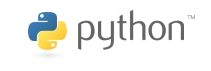

In [2]:
from PIL import Image
import requests
from io import BytesIO

# 下載一張範例圖片進行測試
url = "https://raw.githubusercontent.com/python-pillow/Pillow/master/src/PIL/Image.py"
# 我們改用一個真實圖片網址
img_url = "https://www.python.org/static/community_logos/python-logo.png"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content))

# 顯示圖片資訊
print(f"格式: {img.format}, 尺寸: {img.size}, 模式: {img.mode}")

# 在 Colab 中顯示圖片
display(img)

## 2. 常用操作範例

以下示範如何調整圖片大小與旋轉。

調整大小後的圖片：


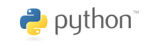

旋轉 45 度後的圖片：


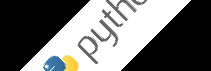

In [4]:
# 調整大小 (Resize)
resized_img = img.resize((150, 50))

# 旋轉圖片 (Rotate)
rotated_img = img.rotate(45)

print("調整大小後的圖片：")
display(resized_img)

print("旋轉 45 度後的圖片：")
display(rotated_img)

## 3. 影像數值化與 NumPy 轉換
影像在電腦中本質上是高度 x 寬度 x 色彩通道 (Height x Width x Channels) 的數字陣列。

In [5]:
import numpy as np

# 將 Pillow 影像轉換為 NumPy 陣列
img_arr = np.array(img)

print(f"陣列形狀 (H, W, C): {img_arr.shape}")
print(f"資料類型: {img_arr.dtype}")

# 拆分 RGB 通道並顯示
r, g, b = img_arr[:,:,0], img_arr[:,:,1], img_arr[:,:,2]
print(f"紅色通道的前 5x5 像素值:\n{r[:5, :5]}")

陣列形狀 (H, W, C): (71, 211, 3)
資料類型: uint8
紅色通道的前 5x5 像素值:
[[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


## 4. 正確的半透明合成 (Alpha Composite)
教材提到，不能直接畫半透明色帶，而應建立透明 Overlay 再進行合成。

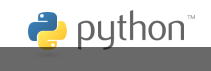

In [2]:
from PIL import Image, ImageDraw
import requests
from io import BytesIO

# 由於環境重啟，我們需要重新獲取圖片物件
img_url = "https://www.python.org/static/community_logos/python-logo.png"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content))

# 1. 準備底圖並轉為 RGBA
base = img.convert("RGBA")

# 2. 建立與底圖相同大小的透明圖層
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)

# 3. 在 Overlay 上畫出半透明黑色矩形 (下方 1/3)
w, h = base.size
draw.rectangle((0, int(h * 2/3), w, h), fill=(0, 0, 0, 150))

# 4. 合成
result = Image.alpha_composite(base, overlay)
display(result.convert("RGB"))

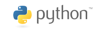

In [10]:
# 縮圖示範

small = img.copy()
small.thumbnail((100, 100))
display(small)

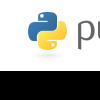

In [17]:
# crop 示範

crop = img.copy()
crop = crop.crop((0, 0, 100, 100))
display(crop)

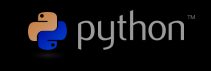

In [29]:
# 負片
# 當圖片變成 NumPy Array 之後，許多影像效果會變得非常直觀。
# negative = 255 - arr
# (200, 50, 20) 會變成 (55, 205, 235)


display(img.convert("RGB").point(lambda x: 255 - x))

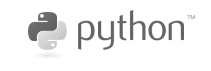

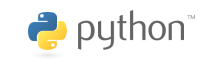

In [30]:
# Convert 模式轉換
# img.convert("L") 轉灰階；
# img.convert("RGBA") 增加 Alpha Channel。



display(img.convert("L"))
display(img.convert("RGBA"))


亮度增強後：


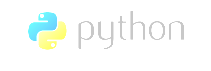

模糊濾鏡後：


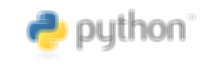

In [24]:
from PIL import ImageEnhance, ImageFilter

# Enhancement 與 Filter

enhancer = ImageEnhance.Brightness(img)
bright = enhancer.enhance(2)  # 亮度加倍

# 濾鏡處理，確保匯入了 ImageFilter
blur = img.filter(ImageFilter.BLUR)

print("亮度增強後：")
display(bright)
print("模糊濾鏡後：")
display(blur)

## 5. 處理 uint8 Overflow (溢位陷阱)
當我們直接將 `uint8` 陣列加值時，超過 255 的部分會環繞回 0，導致畫面亮部變暗。

錯誤處理 (發生 Overflow) 的結果：


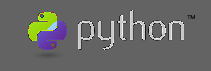

正確處理 (使用 Clip) 的結果：


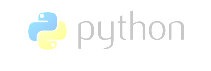

In [7]:
# 錯誤示範：直接相加
bad_bright = img_arr + 100
print("錯誤處理 (發生 Overflow) 的結果：")
display(Image.fromarray(bad_bright))

# 正確示範：轉型 -> 運算 -> Clip -> 轉回 uint8
work = img_arr.astype(np.int16)
work = np.clip(work + 100, 0, 255)
good_bright = work.astype(np.uint8)

print("正確處理 (使用 Clip) 的結果：")
display(Image.fromarray(good_bright))

4.8 畫文字與圖形
==========

Pillow 可以利用 `ImageDraw` 在圖片上加入文字與圖形。

## 6. 綜合實作：活動海報批次生成器 (CSV 驅動)

這個小工具會讀取活動清單，自動在模板上加上半透明色帶與中文標題。

--2026-08-16 13:54:07--  https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf [following]
--2026-08-16 13:54:07--  https://raw.githubusercontent.com/google/fonts/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11941968 (11M) [application/octet-stream]
Saving to: ‘font.ttf’

font.ttf            100%[===================>]  11.39M  51.3MB/s    in 0.2s    

2026-08-16 13:54:08 (51.3 MB/s) - ‘font.ttf’ saved [11941968/119419

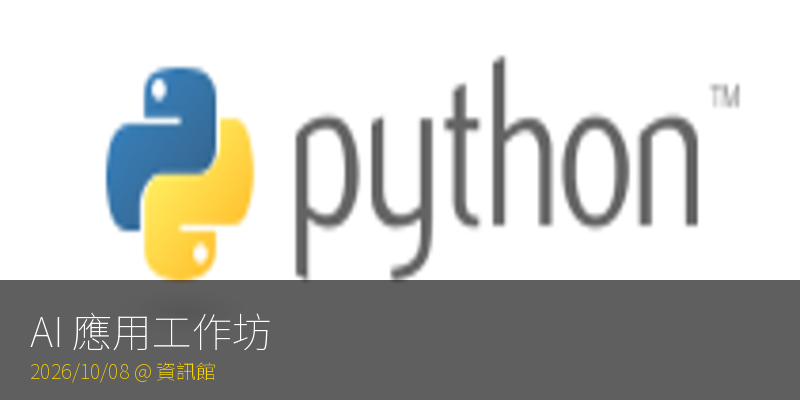

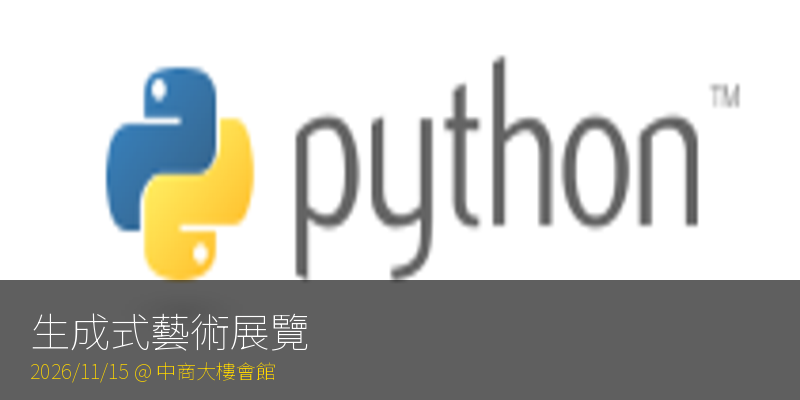

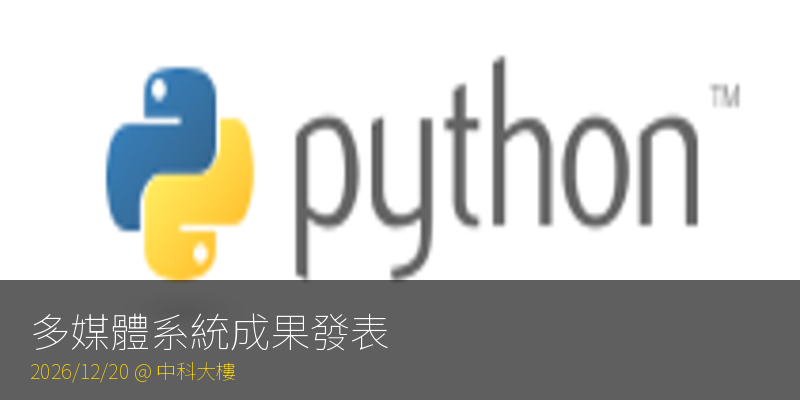

In [26]:
import csv
from PIL import Image, ImageDraw, ImageFont
import os

# 1. 準備模擬資料 (CSV)
data = [
    ['title', 'date', 'location'],
    ['AI 應用工作坊', '2026/10/08', '資訊館'],
    ['生成式藝術展覽', '2026/11/15', '中商大樓會館'],
    ['多媒體系統成果發表', '2026/12/20', '中科大樓']
]

with open('events.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(data)

# 2. 下載繁體中文字型 (Colab 預設可能不支援中文字型)
!wget -O font.ttf https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf
font_path = "font.ttf"

def generate_poster(title, date, location):
    # 開啟底圖 (使用我們先前下載的 Python logo 作為示意底圖，但放大處理)
    base = Image.open(BytesIO(requests.get(img_url).content)).convert("RGBA")
    base = base.resize((800, 400))

    # 建立 Overlay 並畫上半透明黑色標籤 (教材 4.9 節觀念)
    overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    w, h = base.size
    draw.rectangle((0, h-120, w, h), fill=(0, 0, 0, 160))

    # 合成 Overlay
    combined = Image.alpha_composite(base, overlay).convert("RGB")
    draw_text = ImageDraw.Draw(combined)

    # 載入字型
    try:
        title_font = ImageFont.truetype(font_path, 40)
        sub_font = ImageFont.truetype(font_path, 20)
    except:
        title_font = ImageFont.load_default()
        sub_font = ImageFont.load_default()

    # 寫入文字
    draw_text.text((30, h-100), title, font=title_font, fill="white")
    draw_text.text((30, h-45), f"{date} @ {location}", font=sub_font, fill="#FFD700")

    return combined

# 3. 批次執行
print("開始批次生成海報...")
with open('events.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        poster = generate_poster(row['title'], row['date'], row['location'])
        display(poster)
        poster.save(f"poster_{i}.jpg") # 實際應用時可取消註解儲存檔案